# 🔮 Polymarket BTC Binary Markets — ML Trading System

Sistema completo de Machine Learning para predecir y tradear mercados binarios de Bitcoin en Polymarket, usando snapshots cada 10 segundos con datos de precio y order book de Binance y Polymarket.

## Estructura del notebook

| # | Sección | Descripción |
|---|---------|-------------|
| 0 | **Setup** | Imports, configuración global y parámetros |
| 1 | **Carga de datos** | Lectura del CSV y construcción del target |
| 2 | **EDA** | Distribuciones, nulos, correlaciones básicas |
| 3 | **Feature Engineering** | Order book Polymarket, microestructura Binance, tiempo |
| 4 | **Split temporal** | Train/test sin data leakage |
| 5 | **Modelado** | Logistic Regression (baseline) + LightGBM |
| 6 | **Evaluación global** | Accuracy, ROC-AUC, Log Loss en train y test |
| 7 | **Análisis por tiempo** | Performance segmentada por `seconds_left` |
| 8 | **Estrategia EV** | Expected Value por snapshot usando fees reales |
| 9 | **Backtest** | Simulación en USDC con PnL, ROI, drawdown |
| 10 | **Feature Importance** | Top features del modelo LightGBM |
| 11 | **Curva de capital** | Equity curve + drawdown del backtest |

---
> **⚠️ Regla de oro:** split siempre **temporal** (nunca aleatorio) y cero uso de información futura en las features.

---
## 0 · Setup — Imports y configuración global

Todos los parámetros de la estrategia están centralizados aquí. Cambia un valor y re-ejecuta el notebook completo para ver el efecto de punta a punta.

In [73]:
pd.read_csv('polymarket_dataset_5m.csv').tail()

,timestamp,market_slug,seconds_left,market_progress,btc_spot,btc_price_market_open,btc_return_since_open,up_bid_p_1,up_bid_s_1,up_ask_p_1,...,price_vs_ema12,volume_1m,volume_3m,volume_5m,volatility_3m,volatility_5m,buy_volume_last200,sell_volume_last200,trade_imbalance,ret_30s
138,2026-03-19T16:00:12.842957+00:00,btc-updown-5m-1773936000,288,0.04,69391.03,69414.8,-0.000342,0.46,36.55,0.48,...,1.000774,24.9109,77.23317,147.45684,0.000059,0.000949,0.17152,0.08867,0.318421,NaN
139,2026-03-19T16:00:15.950767+00:00,btc-updown-5m-1773936000,285,0.05,69384.52,69414.8,-0.000436,0.47,166.51,0.48,...,1.000774,24.9109,77.23317,147.45684,0.000059,0.000949,0.18891,0.06856,0.467433,NaN
140,2026-03-19T16:00:19.044119+00:00,btc-updown-5m-1773936000,282,0.06,69386.24,69414.8,-0.000411,0.43,29.60,0.45,...,1.000774,24.9109,77.23317,147.45684,0.000059,0.000949,0.13369,0.24121,-0.286796,NaN
141,2026-03-19T16:00:22.133202+00:00,btc-updown-5m-1773936000,279,0.07,69384.52,69414.8,-0.000436,0.45,5.00,0.46,...,1.000774,24.9109,77.23317,147.45684,0.000059,0.000949,0.35796,0.13410,0.454945,NaN
142,2026-03-19T16:00:25.223105+00:00,btc-updown-5m-1773936000,276,0.08,69377.00,69414.8,-0.000545,0.41,66.12,0.44,...,1.000774,24.9109,77.23317,147.45684,0.000059,0.000949,0.87394,0.10710,0.781660,NaN


In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
import lightgbm as lgb

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✅ Imports OK')

✅ Imports OK


In [59]:
# ═══════════════════════════════════════════════════════════════
#  PARÁMETROS GLOBALES  ← modifica aquí para experimentar
# ═══════════════════════════════════════════════════════════════

CSV_PATH      = 'polymarket_pro_dataset_with_resolution.csv'
TRAIN_RATIO   = 0.75    # fracción temporal para entrenamiento

# Estrategia
EV_THRESHOLD  = 0.01    # EV mínimo para entrar (2%). Prueba 0.01, 0.03...
STAKE_USDC    = 10.0    # tamaño fijo por trade en USDC
MIN_LIQUIDITY = 5.0     # tamaño mínimo disponible en ask nivel 1 (USDC)

# Modelo LightGBM
RANDOM_STATE  = 42
LGBM_PARAMS   = dict(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 31,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    random_state      = RANDOM_STATE,
    verbose           = -1,
)

print('⚙️  Configuración cargada')
print(f'   CSV          : {CSV_PATH}')
print(f'   Train ratio  : {TRAIN_RATIO:.0%}')
print(f'   EV threshold : {EV_THRESHOLD:.1%}')
print(f'   Stake        : {STAKE_USDC} USDC')

⚙️  Configuración cargada
   CSV          : polymarket_pro_dataset_with_resolution.csv
   Train ratio  : 75%
   EV threshold : 1.0%
   Stake        : 10.0 USDC


---
## 1 · Carga de datos y construcción del target

### Construcción del target sin data leakage

Cada fila del CSV es un snapshot de un mercado en curso. El resultado (UP/DOWN) sólo se conoce al cierre. Para evitar leakage:

1. Tomamos el **último snapshot** de cada `market_slug` (el de `seconds_left` más pequeño)
2. En ese punto comparamos `btc_spot` vs `btc_price_market_open`: si BTC subió → **UP (1)**
3. Propagamos ese resultado a **todos los snapshots anteriores** del mismo mercado

Cada fila tiene el target correcto pero las features usan sólo información de su propio timestamp.

In [65]:
df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values(['market_slug', 'timestamp']).reset_index(drop=True)

print(f'Filas cargadas   : {len(df):,}')
print(f'Mercados únicos  : {df["market_slug"].nunique()}')
print(f'Rango temporal   : {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'\nColumnas ({len(df.columns)}):')
print(df.columns.tolist())

Filas cargadas   : 22,935
Mercados únicos  : 235
Rango temporal   : 2026-03-16 21:49:43.167141+00:00 → 2026-03-19 08:16:06.394819+00:00

Columnas (56):
['timestamp', 'market_slug', 'btc_spot', 'btc_price_market_open', 'btc_return_since_open', 'seconds_left', 'up_bid_p_1', 'up_bid_s_1', 'up_ask_p_1', 'up_ask_s_1', 'up_bid_p_2', 'up_bid_s_2', 'up_ask_p_2', 'up_ask_s_2', 'up_bid_p_3', 'up_bid_s_3', 'up_ask_p_3', 'up_ask_s_3', 'down_bid_p_1', 'down_bid_s_1', 'down_ask_p_1', 'down_ask_s_1', 'down_bid_p_2', 'down_bid_s_2', 'down_ask_p_2', 'down_ask_s_2', 'down_bid_p_3', 'down_bid_s_3', 'down_ask_p_3', 'down_ask_s_3', 'up_fee_bps', 'down_fee_bps', 'bid_volume_10', 'ask_volume_10', 'orderbook_imbalance', 'mid_price', 'spread', 'ret_1m', 'ret_3m', 'ret_5m', 'ret_10m', 'ema_3', 'ema_6', 'ema_12', 'ema_24', 'ema_ratio', 'price_vs_ema12', 'volume_1m', 'volume_5m', 'volume_10m', 'volatility_5m', 'volatility_10m', 'buy_volume_last200', 'sell_volume_last200', 'trade_imbalance', 'resolution']


In [66]:
# Último snapshot de cada mercado (seconds_left mínimo = más cercano al cierre)
last_snap = (
    df.sort_values('seconds_left')
      .groupby('market_slug')
      .first()
      .reset_index()[['market_slug', 'btc_spot', 'btc_price_market_open']]
)
last_snap['target'] = (last_snap['btc_spot'] >= last_snap['btc_price_market_open']).astype(int)

# Propagar a todos los snapshots del mercado
df = df.merge(last_snap[['market_slug', 'target']], on='market_slug', how='left')

# Reordenar por timestamp global (necesario para el split temporal)
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Target UP   (1) : {df["target"].mean():.2%}')
print(f'Target DOWN (0) : {(1 - df["target"].mean()):.2%}')
print(f'Nulos           : {df["target"].isna().sum()}')

Target UP   (1) : 47.97%
Target DOWN (0) : 52.03%
Nulos           : 0


In [67]:
# ── Retorno por snapshot: ¿cuánto gano/pierdo si invierto 10 USDC ahora? ─────
#
# Lógica:
#   Si compro UP a up_ask_p_1 y el mercado resuelve UP  → cobro 1 USDC por cada USDC apostado
#   Si compro UP a up_ask_p_1 y el mercado resuelve DOWN → pierdo el stake
#
#   Payout bruto si gano : STAKE / ask          (ej: 10 / 0.52 = 19.23 USDC)
#   Beneficio neto       : payout - STAKE       (ej: 19.23 - 10 = 9.23 USDC)
#   Si pierde            : -STAKE               (-10 USDC)
#   Fee                  : STAKE * fee_pct      (se descuenta siempre, ganes o pierdas)
#
# Las columnas resultantes representan el P&L REALIZADO al cierre del mercado,
# visto desde el momento del snapshot (útil para el backtest y para el modelo).

STAKE = 10.0

ask_up = df['up_ask_p_1'].replace(0, np.nan).clip(0.01, 0.99)
ask_dn = df['down_ask_p_1'].replace(0, np.nan).clip(0.01, 0.99)

fee_up = df['up_fee_bps'].fillna(0)   / 10_000 * STAKE
fee_dn = df['down_fee_bps'].fillna(0) / 10_000 * STAKE

# Retorno si compro UP en este snapshot
df['ret_if_up'] = np.where(
    df['target'] == 1,
    (STAKE / ask_up - STAKE) - fee_up,   # gana: payout neto - fee
    -STAKE - fee_up                        # pierde: -stake - fee
).round(4)

# Retorno si compro DOWN en este snapshot
df['ret_if_down'] = np.where(
    df['target'] == 0,
    (STAKE / ask_dn - STAKE) - fee_dn,
    -STAKE - fee_dn
).round(4)

print(f"{'':30} {'UP':>10} {'DOWN':>10}")
print(f"{'Retorno medio (USDC)':30} {df['ret_if_up'].mean():>10.4f} {df['ret_if_down'].mean():>10.4f}")
print(f"{'Retorno si gana (media)':30} {df.loc[df['target']==1, 'ret_if_up'].mean():>10.4f} {df.loc[df['target']==0, 'ret_if_down'].mean():>10.4f}")
print(f"{'Retorno si pierde (media)':30} {df.loc[df['target']==0, 'ret_if_up'].mean():>10.4f} {df.loc[df['target']==1, 'ret_if_down'].mean():>10.4f}")
print(f"{'% snapshots con ret > 0 (UP)':30} {(df['ret_if_up'] > 0).mean():>10.1%}")
print(f"{'% snapshots con ret > 0 (DOWN)':30} {(df['ret_if_down'] > 0).mean():>10.1%}")

                                       UP       DOWN
Retorno medio (USDC)              -6.3777    -5.9679
Retorno si gana (media)           -0.8990    -0.9058
Retorno si pierde (media)        -11.0063   -11.0000
% snapshots con ret > 0 (UP)         0.0%
% snapshots con ret > 0 (DOWN)       0.0%


---
## 2 · EDA — Exploración inicial

Revisamos calidad del dataset (nulos), distribuciones de las variables clave y correlaciones con el target antes de construir features.

In [8]:
print('=== INFO GENERAL ===')
df.info(memory_usage='deep')

=== INFO GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 22935 entries, 0 to 22934
Data columns (total 57 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   timestamp              22935 non-null  datetime64[us, UTC]
 1   market_slug            22935 non-null  str                
 2   btc_spot               22935 non-null  float64            
 3   btc_price_market_open  22935 non-null  float64            
 4   btc_return_since_open  22935 non-null  float64            
 5   seconds_left           22935 non-null  int64              
 6   up_bid_p_1             21936 non-null  float64            
 7   up_bid_s_1             21936 non-null  float64            
 8   up_ask_p_1             22014 non-null  float64            
 9   up_ask_s_1             22014 non-null  float64            
 10  up_bid_p_2             21354 non-null  float64            
 11  up_bid_s_2             21354 non-null  float

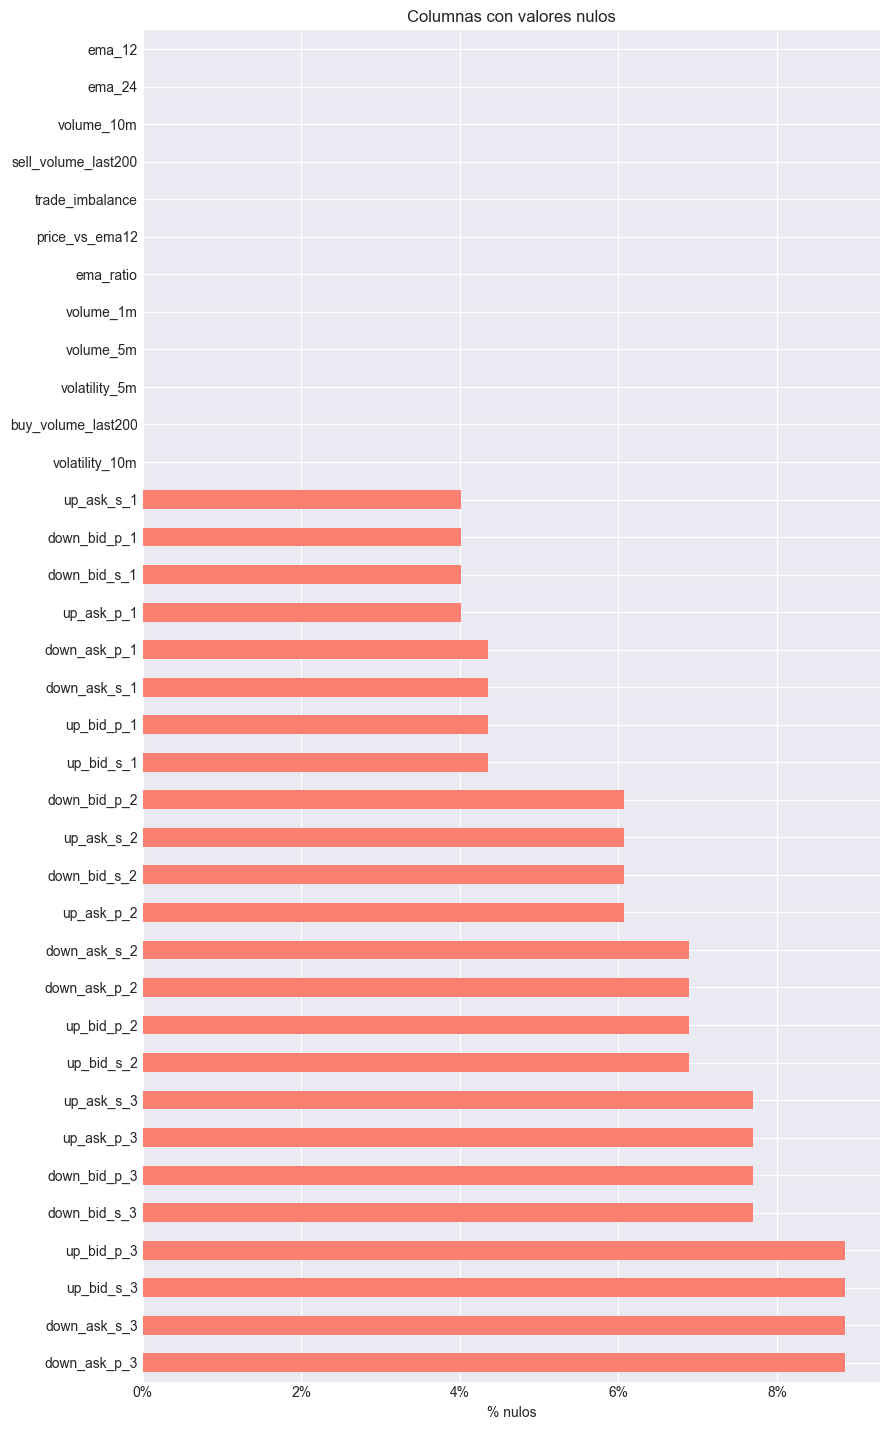

In [9]:
# Valores nulos por columna
null_pct = df.isnull().mean().sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

if len(null_pct) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(null_pct) * 0.4)))
    null_pct.plot(kind='barh', ax=ax, color='salmon')
    ax.set_xlabel('% nulos')
    ax.set_title('Columnas con valores nulos')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    plt.tight_layout()
    plt.show()
else:
    print('✅ Sin valores nulos')

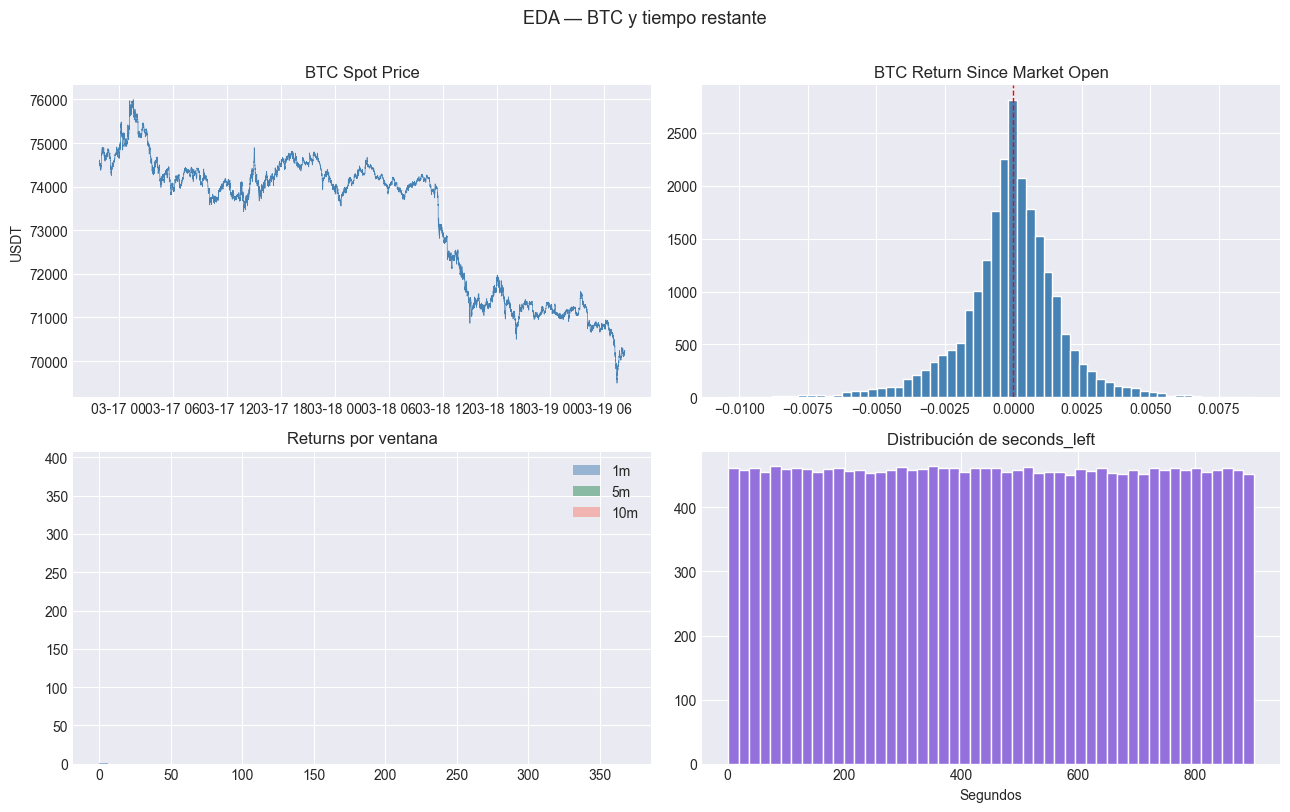

In [10]:
# BTC price, returns y distribución de seconds_left
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(df['timestamp'], df['btc_spot'], linewidth=0.5, color='steelblue')
axes[0,0].set_title('BTC Spot Price')
axes[0,0].set_ylabel('USDT')

axes[0,1].hist(df['btc_return_since_open'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0,1].set_title('BTC Return Since Market Open')

for col, label, color in [('ret_1m','1m','steelblue'),('ret_5m','5m','seagreen'),('ret_10m','10m','salmon')]:
    axes[1,0].hist(df[col].dropna(), bins=60, alpha=0.5, label=label, density=True, color=color)
axes[1,0].set_title('Returns por ventana')
axes[1,0].legend()

axes[1,1].hist(df['seconds_left'].dropna(), bins=50, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Distribución de seconds_left')
axes[1,1].set_xlabel('Segundos')

plt.suptitle('EDA — BTC y tiempo restante', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

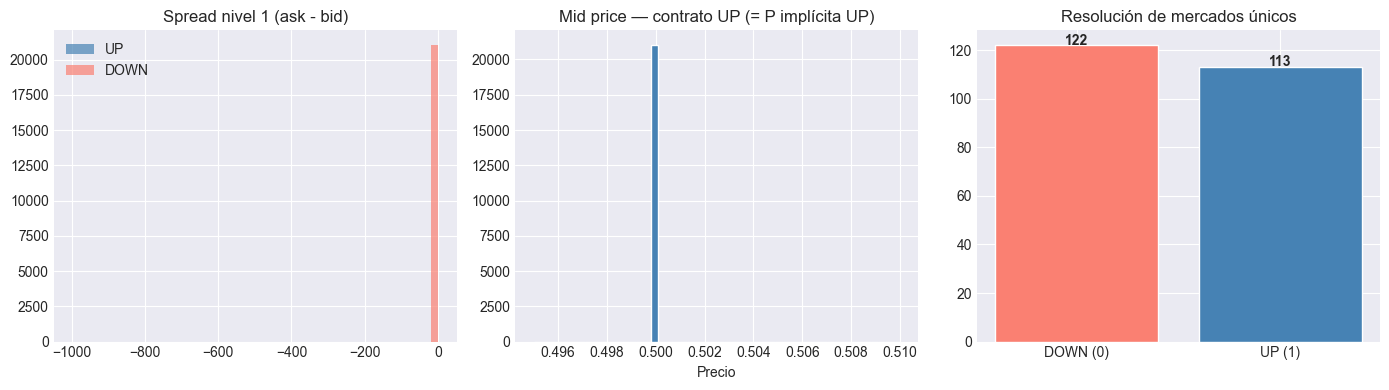

In [11]:
# Order book Polymarket: spread y mid del contrato UP
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

up_spread = df['up_ask_p_1'] - df['up_bid_p_1']
dn_spread = df['down_ask_p_1'] - df['down_bid_p_1']
axes[0].hist(up_spread.dropna(), bins=50, alpha=0.7, label='UP', color='steelblue')
axes[0].hist(dn_spread.dropna(), bins=50, alpha=0.7, label='DOWN', color='salmon')
axes[0].set_title('Spread nivel 1 (ask - bid)')
axes[0].legend()

up_mid = (df['up_ask_p_1'] + df['up_bid_p_1']) / 2
axes[1].hist(up_mid.dropna(), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Mid price — contrato UP (= P implícita UP)')
axes[1].set_xlabel('Precio')

tpm = df.groupby('market_slug')['target'].first().value_counts().sort_index()
axes[2].bar(['DOWN (0)', 'UP (1)'], tpm.values, color=['salmon', 'steelblue'], edgecolor='white')
for i, v in enumerate(tpm.values):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontweight='bold')
axes[2].set_title('Resolución de mercados únicos')

plt.tight_layout()
plt.show()

In [15]:
# Correlación de variables numéricas con el target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = (
    df[num_cols + ['target']].corr()['target']
    .drop('target')
    .sort_values(by='timestamp', key=abs, ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 correlaciones con target')
ax.set_xlabel('Correlación de Pearson')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

KeyError: 'timestamp'

---
## 3 · Feature Engineering

El dataset ya incluye features precalculadas (returns, EMAs, volatilidad, volumen, microestructura Binance). Aquí construimos las **features derivadas del order book de Polymarket** que no están calculadas, más transformaciones y combinaciones útiles.

### Principio: sin leakage
- Los `.diff()` y `.rolling()` se calculan **dentro de cada `market_slug`** (`.groupby().transform()`)
- Esto evita que el diff del primer snapshot de un mercado tome valores del mercado anterior

### Features construidas

| Grupo | Descripción |
|-------|-------------|
| **OB UP** | Spread, mid, imbalance, pressure, depth total 3 niveles, weighted mid |
| **OB DOWN** | Ídem para DOWN |
| **Relativas UP/DOWN** | mid_diff, spread_ratio, imbal_diff, prob implícita y sus cambios |
| **Fees** | Fee en % (desde bps), diferencia UP-DOWN |
| **Tiempo** | Log/sqrt/inv de seconds_left, hora UTC, buckets encoded |
| **Cross** | Interacciones momentum × prob, Binance × Polymarket imbalance |

In [17]:
# ── 3.1 Order book Polymarket — contrato UP ───────────────────────────────────

# Nivel 1 (best bid/ask)
df['up_spread_1']    = df['up_ask_p_1'] - df['up_bid_p_1']
df['up_mid_1']       = (df['up_ask_p_1'] + df['up_bid_p_1']) / 2
total_1              = (df['up_bid_s_1'] + df['up_ask_s_1']).replace(0, np.nan)
df['up_imbalance_1'] = (df['up_bid_s_1'] - df['up_ask_s_1']) / total_1
df['up_pressure_1']  = df['up_bid_s_1'] / total_1

# Depth agregado niveles 1+2+3
df['up_total_bid']   = df['up_bid_s_1'] + df['up_bid_s_2'].fillna(0) + df['up_bid_s_3'].fillna(0)
df['up_total_ask']   = df['up_ask_s_1'] + df['up_ask_s_2'].fillna(0) + df['up_ask_s_3'].fillna(0)
depth_total          = (df['up_total_bid'] + df['up_total_ask']).replace(0, np.nan)
df['up_depth_imbal'] = (df['up_total_bid'] - df['up_total_ask']) / depth_total

# Weighted mid price (pondera bid/ask por el tamaño del lado contrario)
df['up_wmid_1']      = (
    df['up_ask_p_1'] * df['up_bid_s_1'] + df['up_bid_p_1'] * df['up_ask_s_1']
) / total_1

print('✅ Order book UP')

✅ Order book UP


In [18]:
# ── 3.2 Order book Polymarket — contrato DOWN ─────────────────────────────────

df['down_spread_1']    = df['down_ask_p_1'] - df['down_bid_p_1']
df['down_mid_1']       = (df['down_ask_p_1'] + df['down_bid_p_1']) / 2
total_dn               = (df['down_bid_s_1'] + df['down_ask_s_1']).replace(0, np.nan)
df['down_imbalance_1'] = (df['down_bid_s_1'] - df['down_ask_s_1']) / total_dn
df['down_pressure_1']  = df['down_bid_s_1'] / total_dn

df['down_total_bid']   = df['down_bid_s_1'] + df['down_bid_s_2'].fillna(0) + df['down_bid_s_3'].fillna(0)
df['down_total_ask']   = df['down_ask_s_1'] + df['down_ask_s_2'].fillna(0) + df['down_ask_s_3'].fillna(0)
depth_dn               = (df['down_total_bid'] + df['down_total_ask']).replace(0, np.nan)
df['down_depth_imbal'] = (df['down_total_bid'] - df['down_total_ask']) / depth_dn

df['down_wmid_1']      = (
    df['down_ask_p_1'] * df['down_bid_s_1'] + df['down_bid_p_1'] * df['down_ask_s_1']
) / total_dn

print('✅ Order book DOWN')

✅ Order book DOWN


In [19]:
# ── 3.3 Features relativas UP vs DOWN ────────────────────────────────────────

# Diferencias entre contratos en el mismo snapshot
df['mid_diff']         = df['up_mid_1'] - df['down_mid_1']       # > 0 → mercado favorece UP
df['spread_ratio']     = df['up_spread_1'] / df['down_spread_1'].replace(0, np.nan)
df['imbal_diff']       = df['up_imbalance_1'] - df['down_imbalance_1']
df['depth_ratio']      = (
    (df['up_total_bid']   + df['up_total_ask']) /
    (df['down_total_bid'] + df['down_total_ask']).replace(0, np.nan)
)

# Probabilidad implícita: el mid del contrato UP ≈ P(UP) en Polymarket
df['impl_prob_up']     = df['up_mid_1'].clip(0.01, 0.99)
df['impl_prob_dn']     = df['down_mid_1'].clip(0.01, 0.99)

# Cambios de la prob implícita a lo largo del mercado
# ⚠️ Se calcula dentro de cada market_slug para no mezclar mercados distintos
df['impl_chg_1']       = df.groupby('market_slug')['impl_prob_up'].diff(1)
df['impl_chg_6']       = df.groupby('market_slug')['impl_prob_up'].diff(6)   # ~1 min
df['impl_chg_30']      = df.groupby('market_slug')['impl_prob_up'].diff(30)  # ~5 min

# Volatilidad rolling de la prob implícita (dentro de cada mercado)
df['impl_prob_vol']    = (
    df.groupby('market_slug')['impl_chg_1']
      .transform(lambda x: x.rolling(6, min_periods=2).std())
)

print('✅ Features relativas UP/DOWN')

✅ Features relativas UP/DOWN


In [20]:
# ── 3.4 Fees reales (bps → porcentaje) ───────────────────────────────────────
# 1 bps = 0.01%, el dataset los reporta en basis points

df['up_fee_pct']   = df['up_fee_bps']   / 10_000
df['down_fee_pct'] = df['down_fee_bps'] / 10_000
df['fee_diff']     = df['up_fee_pct'] - df['down_fee_pct']

print('✅ Fee features')
print(f'   Fee media UP   : {df["up_fee_pct"].mean():.4%}')
print(f'   Fee media DOWN : {df["down_fee_pct"].mean():.4%}')

✅ Fee features
   Fee media UP   : 10.0325%
   Fee media DOWN : 10.0326%


In [21]:
# ── 3.5 Features de tiempo ────────────────────────────────────────────────────
# seconds_left tiene relación no lineal con la predictibilidad.
# Log y sqrt reducen el skew; inv amplifica señales cerca del cierre.

df['secs_log']        = np.log1p(df['seconds_left'].clip(lower=0))
df['secs_sqrt']       = np.sqrt(df['seconds_left'].clip(lower=0))
df['secs_inv']        = 1 / df['seconds_left'].clip(lower=1)

df['hour_utc']        = df['timestamp'].dt.hour
df['minute_utc']      = df['timestamp'].dt.minute

df['time_bucket']     = pd.cut(
    df['seconds_left'].fillna(9999),
    bins=[-1, 60, 300, 9999],
    labels=['<1m', '1-5m', '>5m']
)
df['time_bucket_enc'] = df['time_bucket'].map({'<1m': 0, '1-5m': 1, '>5m': 2})

print('✅ Time features')

✅ Time features


In [22]:
# ── 3.6 Cross features ────────────────────────────────────────────────────────
# Interacciones entre señales de distinto origen

# Momentum BTC × probabilidad implícita del mercado
df['prob_x_ret1m']       = df['impl_prob_up'] * df['ret_1m'].fillna(0)
df['prob_x_ret5m']       = df['impl_prob_up'] * df['ret_5m'].fillna(0)

# Imbalance Binance × imbalance Polymarket UP
df['binance_x_poly_imb'] = df['orderbook_imbalance'] * df['up_imbalance_1'].fillna(0)

# Trade flow × imbalance Polymarket
df['flow_x_poly_imb']    = df['trade_imbalance'] * df['up_imbalance_1'].fillna(0)

# Return desde apertura × urgencia temporal (señal más pesada cerca del cierre)
df['ret_x_secs_inv']     = df['btc_return_since_open'] * df['secs_inv']

print('✅ Cross features')

✅ Cross features


In [23]:
# ── Lista final de features ───────────────────────────────────────────────────

FEATURES_DATASET = [
    # BTC
    'btc_return_since_open',
    # Binance microestructura
    'bid_volume_10', 'ask_volume_10', 'orderbook_imbalance', 'mid_price', 'spread',
    # Momentum
    'ret_1m', 'ret_3m', 'ret_5m', 'ret_10m',
    # EMAs
    'ema_ratio', 'price_vs_ema12',
    # Volumen
    'volume_1m', 'volume_5m', 'volume_10m',
    # Volatilidad
    'volatility_5m', 'volatility_10m',
    # Trade flow
    'buy_volume_last200', 'sell_volume_last200', 'trade_imbalance',
]

FEATURES_ENGINEERED = [
    # OB UP
    'up_spread_1', 'up_mid_1', 'up_imbalance_1', 'up_pressure_1',
    'up_total_bid', 'up_total_ask', 'up_depth_imbal', 'up_wmid_1',
    # OB DOWN
    'down_spread_1', 'down_mid_1', 'down_imbalance_1', 'down_pressure_1',
    'down_total_bid', 'down_total_ask', 'down_depth_imbal', 'down_wmid_1',
    # Relativas UP/DOWN
    'mid_diff', 'spread_ratio', 'imbal_diff', 'depth_ratio',
    'impl_prob_up', 'impl_prob_dn',
    'impl_chg_1', 'impl_chg_6', 'impl_chg_30', 'impl_prob_vol',
    # Fees
    'up_fee_pct', 'down_fee_pct', 'fee_diff',
    # Tiempo
    'seconds_left', 'secs_log', 'secs_sqrt', 'secs_inv',
    'hour_utc', 'minute_utc', 'time_bucket_enc',
    # Cross
    'prob_x_ret1m', 'prob_x_ret5m',
    'binance_x_poly_imb', 'flow_x_poly_imb', 'ret_x_secs_inv',
]

FEATURE_COLS = FEATURES_DATASET + FEATURES_ENGINEERED

missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f'⚠️  Columnas no encontradas: {missing}')
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f'Features del dataset : {len(FEATURES_DATASET)}')
print(f'Features construidas : {len(FEATURES_ENGINEERED)}')
print(f'Total               : {len(FEATURE_COLS)}')

Features del dataset : 20
Features construidas : 41
Total               : 61


---
## 4 · Split temporal

**¿Por qué temporal y no aleatorio?**

Un split aleatorio en series temporales filtra información del futuro al pasado: el modelo vería snapshots de mercados futuros durante el entrenamiento → métricas infladas que no se reproducen en producción.

El corte correcto: **los primeros `TRAIN_RATIO`% del tiempo → train, el resto → test**. El DataFrame ya está ordenado por `timestamp` global, por lo que basta con un `iloc`.

In [24]:
cut   = int(len(df) * TRAIN_RATIO)
train = df.iloc[:cut].copy()
test  = df.iloc[cut:].copy()

X_train = train[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)
y_train = train['target']
X_test  = test[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)
y_test  = test['target']

print('Split temporal aplicado')
print(f'  TRAIN : {len(train):,} filas   {train["timestamp"].min().date()} → {train["timestamp"].max().date()}')
print(f'  TEST  : {len(test):,} filas   {test["timestamp"].min().date()} → {test["timestamp"].max().date()}')
print(f'\nBalance target:')
print(f'  Train → UP: {y_train.mean():.2%}   DOWN: {(1-y_train.mean()):.2%}')
print(f'  Test  → UP: {y_test.mean():.2%}   DOWN: {(1-y_test.mean()):.2%}')

Split temporal aplicado
  TRAIN : 17,201 filas   2026-03-16 → 2026-03-18
  TEST  : 5,734 filas   2026-03-18 → 2026-03-19

Balance target:
  Train → UP: 48.90%   DOWN: 51.10%
  Test  → UP: 45.15%   DOWN: 54.85%


---
## 5 · Entrenamiento de modelos

Entrenamos dos modelos que predicen `P(UP | features)`:

- **Logistic Regression** — baseline lineal. Interpretable, requiere features escaladas.
- **LightGBM** — gradient boosting sobre árboles. Captura no-linealidades e interacciones entre features; generalmente gana en datos tabulares.

La salida que nos interesa no es la clase predicha sino la **probabilidad**, que es la entrada al cálculo de EV.

In [25]:
# ── Logistic Regression ───────────────────────────────────────────────────────
print('Entrenando Logistic Regression...')

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, C=0.1, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)
print('✅ Logistic Regression OK')

Entrenando Logistic Regression...
✅ Logistic Regression OK


In [26]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
print('Entrenando LightGBM...')

lgbm = lgb.LGBMClassifier(**LGBM_PARAMS)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ]
)
print(f'\n✅ LightGBM OK  (best iteration: {lgbm.best_iteration_})')

Entrenando LightGBM...

✅ LightGBM OK  (best iteration: 44)


---
## 6 · Evaluación global

### ¿Por qué Log Loss es la métrica más importante?

La estrategia se basa en EV calculado con las probabilidades del modelo. Si esas probabilidades están mal calibradas (el modelo dice `P(UP)=0.9` cuando en realidad es `0.6`), el EV calculado es incorrecto y los trades son malos aunque el accuracy sea alto.

- **Log Loss bajo** → probabilidades bien calibradas → EV fiable → estrategia potencialmente rentable
- **ROC-AUC** → capacidad discriminativa independiente del umbral. Un valor de `0.55` ya es exploitable.
- **Baseline** = probabilidad implícita del mercado: nuestro modelo debe superarla para justificar su uso.

In [27]:
models_dict = {
    'LogisticRegression': (lr, scaler),
    'LightGBM':           (lgbm, None),
}
all_preds = {}

print(f"{'Modelo':<22} {'Split':<6} {'Accuracy':>10} {'ROC-AUC':>10} {'LogLoss':>10}")
print('─' * 62)

for name, (model, sc) in models_dict.items():
    Xtr = sc.transform(X_train) if sc else X_train
    Xte = sc.transform(X_test)  if sc else X_test
    for split_name, X, y in [('TRAIN', Xtr, y_train), ('TEST', Xte, y_test)]:
        p    = model.predict_proba(X)[:, 1]
        acc  = accuracy_score(y, (p >= 0.5).astype(int))
        auc  = roc_auc_score(y, p)
        ll   = log_loss(y, p)
        print(f"{name:<22} {split_name:<6} {acc:>10.4f} {auc:>10.4f} {ll:>10.4f}")
        if split_name == 'TEST':
            all_preds[name] = p

# Baseline: probabilidad implícita del mercado
impl = test['impl_prob_up'].fillna(0.5).values
print('─' * 62)
print(f"{'Baseline (impl prob)':<22} {'TEST':<6} "
      f"{accuracy_score(y_test,(impl>=0.5).astype(int)):>10.4f} "
      f"{roc_auc_score(y_test,impl):>10.4f} "
      f"{log_loss(y_test,impl):>10.4f}")
all_preds['Baseline'] = impl

Modelo                 Split    Accuracy    ROC-AUC    LogLoss
──────────────────────────────────────────────────────────────
LogisticRegression     TRAIN      0.7891     0.8799     0.4341
LogisticRegression     TEST       0.6723     0.8329     0.5888
LightGBM               TRAIN      0.9318     0.9833     0.2656
LightGBM               TEST       0.7178     0.8678     0.4847
──────────────────────────────────────────────────────────────
Baseline (impl prob)   TEST       0.4513     0.4998     0.6931


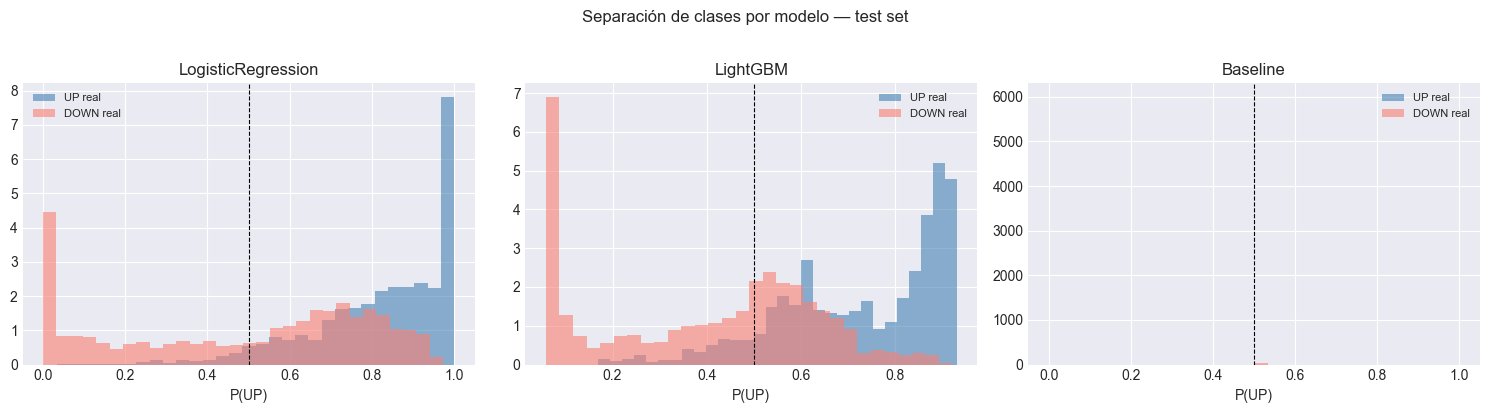

In [28]:
# Distribución de probabilidades predichas por clase real
fig, axes = plt.subplots(1, len(all_preds), figsize=(5 * len(all_preds), 4))
if len(all_preds) == 1:
    axes = [axes]

for ax, (name, probs) in zip(axes, all_preds.items()):
    ax.hist(probs[y_test.values == 1], bins=30, alpha=0.6,
            label='UP real', color='steelblue', density=True)
    ax.hist(probs[y_test.values == 0], bins=30, alpha=0.6,
            label='DOWN real', color='salmon', density=True)
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel('P(UP)')
    ax.legend(fontsize=8)

plt.suptitle('Separación de clases por modelo — test set', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 7 · Análisis por bucket de tiempo restante

La hipótesis: **el modelo es más preciso cuanto menos tiempo queda**. Cerca del cierre, la incertidumbre sobre el resultado colapsa y las señales del order book y el precio de BTC son más determinantes.

Este análisis tiene implicaciones directas para la estrategia: si el modelo es mucho mejor en `<1m`, una estrategia que solo opera en los últimos 60 segundos puede tener mejor win rate aunque genere menos trades.

In [29]:
test_eval              = test.copy()
test_eval['pred_prob'] = lgbm.predict_proba(X_test)[:, 1]

bucket_results = []
print(f"{'Bucket':<8} {'N':>8} {'Accuracy':>10} {'ROC-AUC':>10} {'LogLoss':>10}")
print('─' * 50)

for bucket in ['<1m', '1-5m', '>5m']:
    sub = test_eval[test_eval['time_bucket'] == bucket]
    if len(sub) < 10:
        print(f"{bucket:<8} {'<10 obs':>8}")
        continue
    y, p = sub['target'], sub['pred_prob']
    acc  = accuracy_score(y, (p >= 0.5).astype(int))
    try:
        auc = roc_auc_score(y, p)
    except:
        auc = float('nan')
    ll   = log_loss(y, p)
    print(f"{bucket:<8} {len(sub):>8,} {acc:>10.4f} {auc:>10.4f} {ll:>10.4f}")
    bucket_results.append({'bucket': bucket, 'n': len(sub),
                            'accuracy': acc, 'roc_auc': auc, 'log_loss': ll})

bucket_df = pd.DataFrame(bucket_results)

Bucket          N   Accuracy    ROC-AUC    LogLoss
──────────────────────────────────────────────────
<1m           387     0.9819     1.0000     0.1311
1-5m        1,535     0.8521     0.9523     0.3359
>5m         3,812     0.6369     0.7867     0.5805


---
## 8 · Estrategia de Expected Value

### Fórmula con fees reales del dataset

Para cada snapshot calculamos el EV neto usando el **ask real** del order book y la **fee real** del mercado (en bps):

$$EV_{up} = P(UP) \cdot \left(\frac{1}{ask_{up}} - 1\right) - P(DOWN) - fee_{up}$$

$$EV_{down} = P(DOWN) \cdot \left(\frac{1}{ask_{down}} - 1\right) - P(UP) - fee_{down}$$

**Condiciones de entrada:**
- `max(EV_up, EV_down) > EV_THRESHOLD`
- `up_ask_s_1` o `down_ask_s_1` ≥ `MIN_LIQUIDITY` (hay suficiente size en el libro)

In [ ]:
p_up_arr = lgbm.predict_proba(X_test)[:, 1]

test_ev         = test.copy()
test_ev['p_up'] = p_up_arr
test_ev['p_dn'] = 1 - p_up_arr

# Ask prices nivel 1 (precio real al que compraríamos)
ask_up = test_ev['up_ask_p_1'].replace(0, np.nan).clip(0.01, 0.99)
ask_dn = test_ev['down_ask_p_1'].replace(0, np.nan).clip(0.01, 0.99)

# EV incluyendo fee real de cada mercado
test_ev['ev_up']   = (
    test_ev['p_up'] * (1.0 / ask_up - 1)
    - test_ev['p_dn']
    - test_ev['up_fee_pct'].fillna(0)
)
test_ev['ev_down'] = (
    test_ev['p_dn'] * (1.0 / ask_dn - 1)
    - test_ev['p_up']
    - test_ev['down_fee_pct'].fillna(0)
)
test_ev['best_ev'] = test_ev[['ev_up', 'ev_down']].max(axis=1)

# Señal
test_ev['signal'] = np.where(
    test_ev['best_ev'] > EV_THRESHOLD,
    np.where(test_ev['ev_up'] >= test_ev['ev_down'], 'UP', 'DOWN'),
    'HOLD'
)

# Filtro de liquidez (ask_size nivel 1)
insuf = (
    ((test_ev['signal'] == 'UP')   & (test_ev['up_ask_s_1'].fillna(0)   < MIN_LIQUIDITY)) |
    ((test_ev['signal'] == 'DOWN') & (test_ev['down_ask_s_1'].fillna(0) < MIN_LIQUIDITY))
)
test_ev.loc[insuf, 'signal'] = 'HOLD'

print('Distribución de señales:')
print(test_ev['signal'].value_counts().to_string())
print(f'\nDescartadas por liquidez : {insuf.sum():,}')
print(f'EV medio en señales      : {test_ev.loc[test_ev["signal"]!="HOLD", "best_ev"].mean():.4f}')

Distribución de señales:
signal
HOLD    5734

Descartadas por liquidez : 0
EV medio en señales      : nan


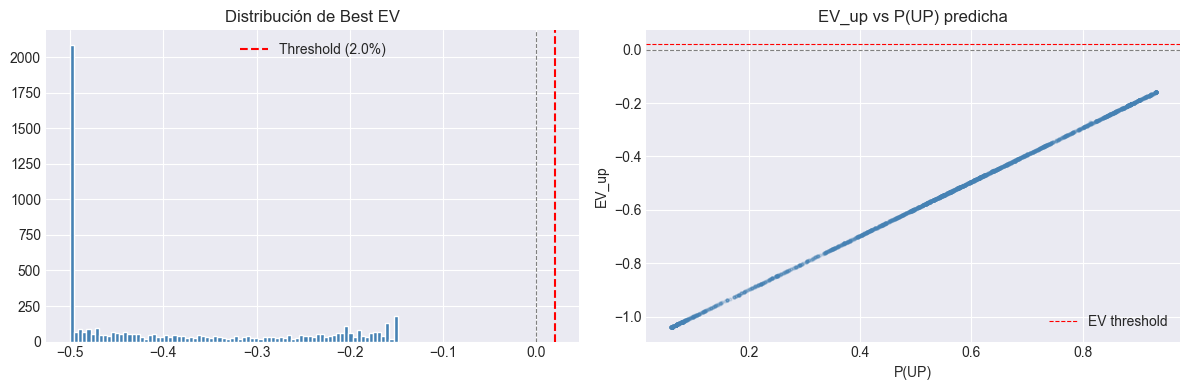

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución del best EV
axes[0].hist(test_ev['best_ev'].clip(-0.5, 0.5), bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(EV_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({EV_THRESHOLD:.1%})')
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Distribución de Best EV')
axes[0].legend()

# EV_up vs P(UP) predicha
idx = test_ev.sample(min(3000, len(test_ev))).index
axes[1].scatter(test_ev.loc[idx, 'p_up'], test_ev.loc[idx, 'ev_up'],
                alpha=0.2, s=4, color='steelblue')
axes[1].axhline(EV_THRESHOLD, color='red', linewidth=0.8, linestyle='--', label='EV threshold')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('EV_up vs P(UP) predicha')
axes[1].set_xlabel('P(UP)')
axes[1].set_ylabel('EV_up')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9 · Backtest

### Reglas de la simulación

| Regla | Implementación |
|-------|----------------|
| Una entrada por mercado | `drop_duplicates(subset='market_slug', keep='first')` |
| Precio de entrada | `up_ask_p_1` / `down_ask_p_1` (nunca mid) |
| Liquidez mínima | `up_ask_s_1` o `down_ask_s_1` ≥ `MIN_LIQUIDITY` |
| Fee | `up_fee_bps` / `down_fee_bps` real de cada snapshot |
| Resolución | `target` (resultado final del mercado) |

In [33]:
trades = (
    test_ev[test_ev['signal'] != 'HOLD']
    .drop_duplicates(subset='market_slug', keep='first')
    .copy()
)

print(f'Snapshots en test         : {len(test_ev):,}')
print(f'Señales generadas         : {(test_ev["signal"]!="HOLD").sum():,}')
print(f'Trades únicos (1/mercado) : {len(trades):,}')

if len(trades) == 0:
    print('\n⚠️  Sin trades. Reduce EV_THRESHOLD (p.ej. a 0.01 o 0.005).')
else:
    trades['won'] = (
        ((trades['signal'] == 'UP')   & (trades['target'] == 1)) |
        ((trades['signal'] == 'DOWN') & (trades['target'] == 0))
    )

    # Precio ask y fee del contrato elegido
    entry_ask = np.where(
        trades['signal'] == 'UP',
        trades['up_ask_p_1'].values,
        trades['down_ask_p_1'].values
    )
    entry_fee = np.where(
        trades['signal'] == 'UP',
        trades['up_fee_pct'].fillna(0).values,
        trades['down_fee_pct'].fillna(0).values
    )

    payout    = 1.0 / np.clip(entry_ask, 0.01, 0.99)
    gross_pnl = np.where(trades['won'], STAKE_USDC * (payout - 1), -STAKE_USDC)
    fee_cost  = STAKE_USDC * entry_fee
    net_pnl   = gross_pnl - fee_cost

    trades['entry_ask'] = entry_ask
    trades['gross_pnl'] = gross_pnl
    trades['fee_cost']  = fee_cost
    trades['net_pnl']   = net_pnl

    equity = trades['net_pnl'].cumsum()
    dd     = equity - equity.cummax()

    n_up   = (trades['signal'] == 'UP').sum()
    n_down = (trades['signal'] == 'DOWN').sum()

    print(f'\n══════════════════════════════════════')
    print(f'  RESULTADOS DEL BACKTEST')
    print(f'══════════════════════════════════════')
    print(f'  Trades          : {len(trades):,}  (UP: {n_up}  DOWN: {n_down})')
    print(f'  Win Rate        : {trades["won"].mean():.2%}')
    print(f'  PnL total       : {net_pnl.sum():+.2f} USDC')
    print(f'  Total apostado  : {len(trades) * STAKE_USDC:.2f} USDC')
    print(f'  ROI             : {net_pnl.sum() / (len(trades)*STAKE_USDC):+.2%}')
    print(f'  Max Drawdown    : {dd.min():+.2f} USDC')
    print(f'  Avg PnL/trade   : {net_pnl.mean():+.4f} USDC')
    print(f'  Avg fee/trade   : {fee_cost.mean():.4f} USDC')
    print(f'  Avg EV entrada  : {trades["best_ev"].mean():.4f}')

    uniq = test_ev.drop_duplicates(subset='market_slug', keep='first')
    baseline_wr = (uniq['target'] == 1).mean()
    print(f'\n  ── vs Baseline (siempre UP) ──')
    print(f'  Baseline WR     : {baseline_wr:.2%}')
    print(f'  Estrategia WR   : {trades["won"].mean():.2%}  ({trades["won"].mean()-baseline_wr:+.2%})')

Snapshots en test         : 5,734
Señales generadas         : 0
Trades únicos (1/mercado) : 0

⚠️  Sin trades. Reduce EV_THRESHOLD (p.ej. a 0.01 o 0.005).


In [ ]:
if len(trades) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    trades['net_pnl'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].axvline(0, color='red', linestyle='--')
    axes[0].set_title('PnL por trade')
    axes[0].set_xlabel('Net PnL (USDC)')

    vc = trades['won'].value_counts().sort_index()
    axes[1].bar(['Perdido', 'Ganado'], vc.values, color=['salmon','steelblue'], edgecolor='white')
    for i, v in enumerate(vc.values):
        axes[1].text(i, v+0.3, str(v), ha='center', fontweight='bold')
    axes[1].set_title('Ganados vs Perdidos')

    colors_scatter = ['steelblue' if w else 'salmon' for w in trades['won']]
    axes[2].scatter(trades['best_ev'], trades['net_pnl'], c=colors_scatter, alpha=0.5, s=15)
    axes[2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[2].set_title('EV al entrar vs PnL real')
    axes[2].set_xlabel('Best EV')
    axes[2].set_ylabel('Net PnL (USDC)')

    plt.tight_layout()
    plt.show()

---
## 10 · Feature Importance

LightGBM reporta importancias basadas en cuántas veces usa cada feature para hacer un split. Útil para:
- Confirmar qué señales tienen poder predictivo real
- Identificar features redundantes o con importancia 0 (candidatas a eliminar)
- Guiar la siguiente iteración de feature engineering

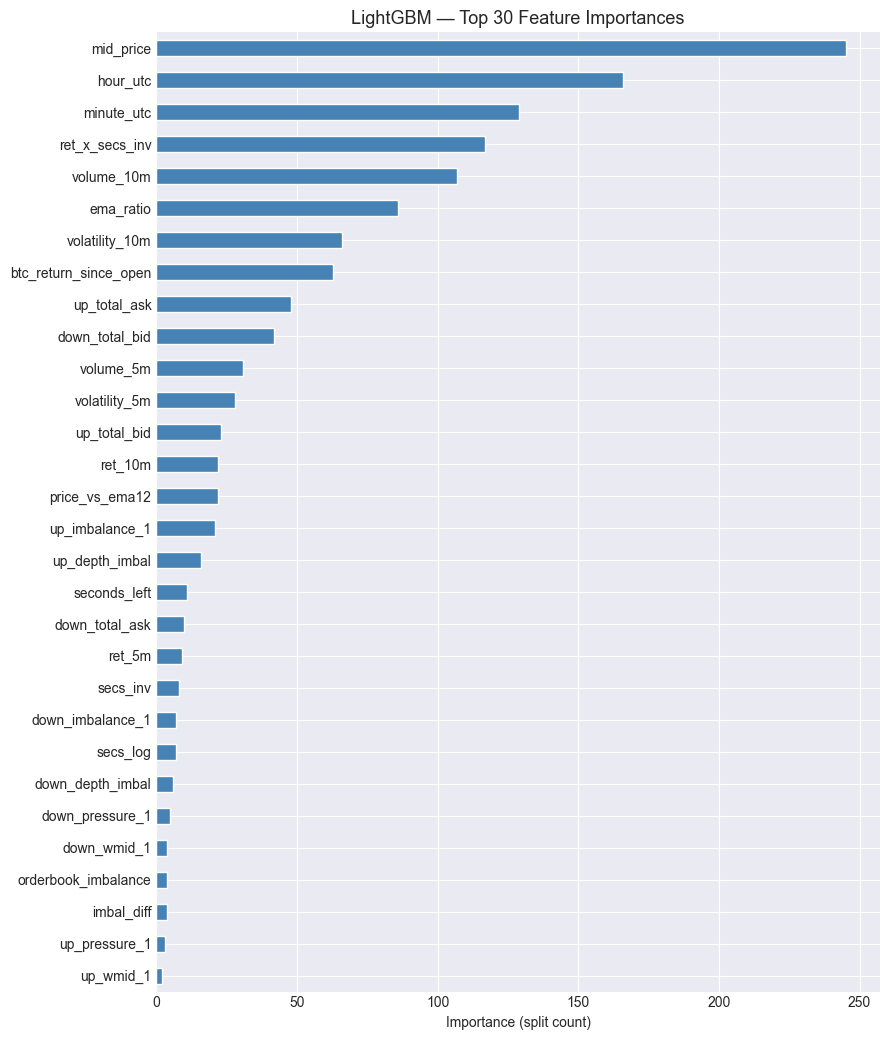

Features con importancia = 0 : 27

Top 15:
mid_price                245
hour_utc                 166
minute_utc               129
ret_x_secs_inv           117
volume_10m               107
ema_ratio                 86
volatility_10m            66
btc_return_since_open     63
up_total_ask              48
down_total_bid            42
volume_5m                 31
volatility_5m             28
up_total_bid              23
ret_10m                   22
price_vs_ema12            22


In [41]:
TOP_N = 30

importance = pd.Series(
    lgbm.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(5, TOP_N * 0.35)))
importance.head(TOP_N).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'LightGBM — Top {TOP_N} Feature Importances', fontsize=13)
ax.set_xlabel('Importance (split count)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Features con importancia = 0 : {(importance == 0).sum()}')
print('\nTop 15:')
print(importance.head(15).to_string())

---
## 11 · Curva de capital

La equity curve muestra el PnL acumulado trade a trade. El drawdown (panel inferior) es la pérdida desde el último máximo en cada punto — la medida de riesgo más intuitiva.

In [42]:
if len(trades) > 0:
    equity_vals = trades['net_pnl'].cumsum().values
    dd_vals     = (trades['net_pnl'].cumsum() - trades['net_pnl'].cumsum().cummax()).values
    x           = np.arange(len(equity_vals))

    fig = plt.figure(figsize=(13, 7))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x, equity_vals, color='royalblue', linewidth=1.5, label='Equity (USDC)')
    ax1.fill_between(x, equity_vals, alpha=0.1, color='royalblue')
    ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax1.set_ylabel('PnL acumulado (USDC)')
    ax1.set_title('Curva de Capital — Estrategia EV Polymarket BTC', fontsize=13)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(x, dd_vals, alpha=0.55, color='crimson', label='Drawdown')
    ax2.set_ylabel('Drawdown (USDC)')
    ax2.set_xlabel('Trade #')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('equity_curve.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Gráfico guardado: equity_curve.png')
else:
    print('⚠️  Sin trades. Reduce EV_THRESHOLD.')

⚠️  Sin trades. Reduce EV_THRESHOLD.


---
## 📝 Próximos pasos y experimentos sugeridos

### Ajuste rápido de parámetros (modifica en celda 0)
```python
EV_THRESHOLD  = [0.005, 0.01, 0.02, 0.03]   # más bajo → más trades, mayor riesgo
STAKE_USDC    = [5, 10, 25]                  # tamaño de posición
MIN_LIQUIDITY = [1, 5, 10]                   # filtro de liquidez en ask_s_1
TRAIN_RATIO   = [0.70, 0.75, 0.80]           # longitud del train set
```

### Modelado
- [ ] **Calibración de probabilidades** (`CalibratedClassifierCV`) — mejora el log loss directamente
- [ ] **Modelo específico para `<1m`** — entrenar un LightGBM sólo con snapshots del último minuto
- [ ] **Walk-forward validation** — múltiples ventanas de train/test consecutivas

### Feature engineering
- [ ] **Ratio `up_ask_p_1 / down_ask_p_1`** — señal de consenso relativo entre contratos
- [ ] **Variación del spread** dentro del mercado (¿se está estrechando/ampliando?)
- [ ] **RSI y Bollinger Bands** sobre `btc_spot`
- [ ] **Agresividad del flow**: `buy_volume_last200 / volume_1m`
- [ ] **Diferencia entre `mid_price` (Binance) y `up_mid_1` (Polymarket)** como señal de divergencia

### Estrategia
- [ ] **Kelly criterion** en lugar de stake fijo: `f* = EV / (payout - 1)` (con cap para no over-bet)
- [ ] Filtrar entradas a sólo el bucket `<1m` donde el modelo es más preciso
- [ ] Añadir un **umbral de confianza** adicional: solo entrar si `p_up > 0.60` o `p_dn > 0.60`